In [1]:
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font="Linux Biolinum O", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('../data/operation-*.txt')]
for frame in frames:
    if 'num_participant' not in frame:
        frame['num_participant'] = 10000
data = pd.concat(frames, ignore_index=True)
data = data[data['comment'].isna()]

data = data[(data['num_concurrent'] == 1) | (data['operation'] == 'repair') & (data['num_concurrent'] == 2)]
data = data[data['num_participant'] == 10000]
data["outer_coding"] = list(zip(data["outer_n"], data["outer_k"]))
data["inner_coding"] = list(zip(data["inner_n"], data["inner_k"]))

def protocol_operation(row):
    return f'{row["protocol"].capitalize()} - {row["operation"]}'

def protocol_inner_coding(row):
    return f'{row["protocol"].capitalize()} - ({int(row["inner_n"])}, {int(row["inner_k"])})'

def protocol_outer_coding(row):
    return f'{row["protocol"].capitalize()} - ({int(row["outer_n"])}, {int(row["outer_k"])})'

data["Protocol - Operation"] = data.apply(protocol_operation, axis=1)
data["Protocol - Inner Code"] = data.apply(protocol_inner_coding, axis=1)
data["Protocol - Outer Code"] = data.apply(protocol_outer_coding, axis=1)
data

,comment,peer,operation,latency,protocol,inner_k,inner_n,outer_k,outer_n,num_concurrent,num_participant,key,outer_coding,inner_coding,Protocol - Operation,Protocol - Inner Code,Protocol - Outer Code
1,NaN,http://ec2-18-192-100-117.eu-central-1.compute...,put,23.694990,entropy,32.0,80.0,4.0,5.0,1.0,10000.0,NaN,"(5.0, 4.0)","(80.0, 32.0)",Entropy - put,"Entropy - (80, 32)","Entropy - (5, 4)"
3,NaN,http://ec2-18-192-100-117.eu-central-1.compute...,get,12.295594,entropy,32.0,80.0,4.0,5.0,1.0,10000.0,NaN,"(5.0, 4.0)","(80.0, 32.0)",Entropy - get,"Entropy - (80, 32)","Entropy - (5, 4)"
14,NaN,NaN,repair,0.040989,kademlia,16.0,40.0,8.0,10.0,2.0,10000.0,6dceee2b48a2fdda4b82b7eb2f8f394cb7b387c876caf7...,"(10.0, 8.0)","(40.0, 16.0)",Kademlia - repair,"Kademlia - (40, 16)","Kademlia - (10, 8)"
15,NaN,NaN,repair,2.867517,kademlia,16.0,40.0,8.0,10.0,2.0,10000.0,0cf5062970ef9416a044998312b3b7e13c9ac7c61efe69...,"(10.0, 8.0)","(40.0, 16.0)",Kademlia - repair,"Kademlia - (40, 16)","Kademlia - (10, 8)"
26,NaN,NaN,repair,3.528400,entropy,32.0,80.0,4.0,5.0,2.0,10000.0,7e54777e1a5590a432a015ac89559f08a3eba79335fc97...,"(5.0, 4.0)","(80.0, 32.0)",Entropy - repair,"Entropy - (80, 32)","Entropy - (5, 4)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19507,NaN,http://ec2-13-244-105-240.af-south-1.compute.a...,get,14.893970,kademlia,32.0,80.0,4.0,5.0,1.0,10000.0,NaN,"(5.0, 4.0)","(80.0, 32.0)",Kademlia - get,"Kademlia - (80, 32)","Kademlia - (5, 4)"
20000,NaN,http://ec2-18-167-121-124.ap-east-1.compute.am...,put,25.660162,entropy,16.0,40.0,8.0,10.0,1.0,10000.0,NaN,"(10.0, 8.0)","(40.0, 16.0)",Entropy - put,"Entropy - (40, 16)","Entropy - (10, 8)"
20002,NaN,http://ec2-18-167-121-124.ap-east-1.compute.am...,get,11.803886,entropy,16.0,40.0,8.0,10.0,1.0,10000.0,NaN,"(10.0, 8.0)","(40.0, 16.0)",Entropy - get,"Entropy - (40, 16)","Entropy - (10, 8)"
20813,NaN,NaN,repair,2.233638,kademlia,32.0,80.0,4.0,5.0,2.0,10000.0,be8648abffe38a0ff4694c4e9a8174155b6dd04c5f003c...,"(5.0, 4.0)","(80.0, 32.0)",Kademlia - repair,"Kademlia - (80, 32)","Kademlia - (5, 4)"


In [2]:
entropy_palette = sns.cubehelix_palette(rot=0., light=0.75, n_colors=6)
entropy_palette

[[0.7418833583391004, 0.7311938613148788, 0.8997442967474049],
 [0.6175374779546328, 0.6041632345713187, 0.8150463603844675],
 [0.4949486351403306, 0.48058815840061514, 0.7070220684352172],
 [0.37411682989619377, 0.3604686328027682, 0.5756714208996541],
 [0.2588557586159169, 0.24751407501730102, 0.4263480935640138],
 [0.14148134988081507, 0.13419418119184928, 0.2490971979392541]]

In [3]:
kademlia_palette = sns.cubehelix_palette(start=2.5, rot=0., dark=0.25, n_colors=6)
kademlia_palette

[[0.7688955495044795, 0.8833890866885565, 0.9010191872049211],
 [0.6016556562168348, 0.7798523644657366, 0.8072916938408304],
 [0.45802734110871657, 0.6724632116242254, 0.7054827692733565],
 [0.32843538317291665, 0.5540623513079217, 0.5888051518646674],
 [0.2179759825470709, 0.42810758474738886, 0.46046435666282204],
 [0.12929653130520954, 0.29902355028873584, 0.3251586883813918]]

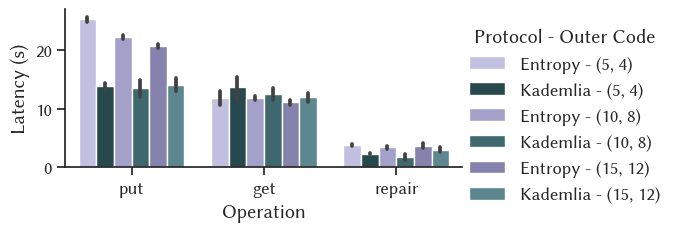

In [4]:
# hue_order = ["entropy - put", "kademlia - put", "entropy - get", "kademlia - get", "entropy - repair", "kademlia - repair"]
hue_order = [f"{p} - {c}" for c in ("(5, 4)", "(10, 8)", "(15, 12)") for p in ("Entropy", "Kademlia")]
palette = [c for p in zip(entropy_palette, reversed(kademlia_palette)) for c in p]

ax = sns.catplot(data=data[data["inner_coding"] == (80, 32)], 
    kind="bar",
    # x="outer_coding", 
    x="operation", 
    y="latency", 
    # hue="protocol - operation",
    # order=[(5, 4), (10, 8), (15, 12)],
    hue="Protocol - Outer Code",
    order=["put", "get", "repair"],
    hue_order=hue_order, palette=palette,
    # legend=False,
    height=2.56, aspect=2.)
# ax.add_legend(label_order = ["entropy - put", "entropy - get", "entropy - repair", "kademlia - put", "kademlia - get", "kademlia - repair"])
ax \
.set_xlabels("Outer Code") \
.set_xlabels("Operation") \
.set_ylabels("Latency (s)") \
.savefig("../../graphs/operation-outer.pdf")

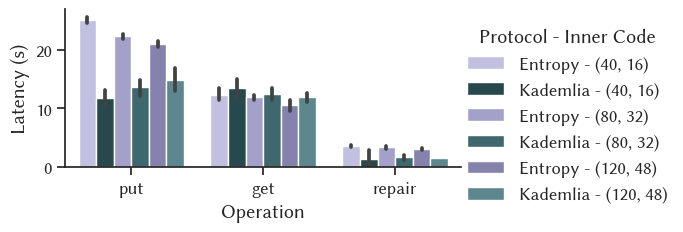

In [5]:
hue_order = [f"{p} - {c}" for c in ("(40, 16)", "(80, 32)", "(120, 48)") for p in ("Entropy", "Kademlia")]

sns.catplot(data=data[data["outer_coding"] == (10, 8)], 
    kind="bar",
    x="operation", y="latency", 
    # hue="protocol - operation",
    # order=[(40, 16), (80, 32), (120, 48)],
    hue="Protocol - Inner Code",
    order=["put", "get", "repair"],
    hue_order=hue_order, palette=palette,
    height=2.56, aspect=2.) \
.set_xlabels("Inner Code") \
.set_xlabels("Operation") \
.set_ylabels("Latency (s)") \
.savefig("../../graphs/operation-inner.pdf")